In [1]:
#Cell 1 — Imports and Load Features
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
from sklearn.metrics import mean_squared_error, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.float_format', '{:.4f}'.format)
plt.rcParams['figure.figsize'] = (14, 5)
sns.set_theme(style='whitegrid')

# Load feature table
df = pd.read_parquet('../data/features/ca1_foods_features.parquet')
df['date'] = pd.to_datetime(df['date'])

print(f"✅ Loaded: {df.shape}")
print(f"   Date range: {df['date'].min().date()} → {df['date'].max().date()}")
print(f"   Products:   {df['id'].nunique()}")
print(df.head(3))

✅ Loaded: (2708745, 32)
   Date range: 2011-02-26 → 2016-04-24
   Products:   1437
   lag_7  lag_14  lag_28  roll_mean_7  roll_mean_14  roll_mean_28  roll_std_7  \
0 1.0000  3.0000  3.0000       1.1429        1.0714        1.2273      0.8997   
1 2.0000  0.0000  0.0000       1.4286        1.2143        1.2609      0.7868   
2 0.0000  2.0000  0.0000       1.1429        1.2143        1.2083      0.8997   

   roll_std_14  roll_std_28  day_of_week  ...  sell_price  price_change_pct  \
0       1.1411       1.2699            5  ...      2.0000            0.0000   
1       1.1217       1.2511            6  ...      2.0000            0.0000   
2       1.1217       1.2504            0  ...      2.0000            0.0000   

   price_vs_mean  is_price_drop  units_sold                           id  \
0         0.9229              0           2  FOODS_1_001_CA_1_validation   
1         0.9229              0           2  FOODS_1_001_CA_1_validation   
2         0.9229              0           0  FO

In [2]:
#Cell 2 — Define Features and Target
FEATURE_COLS = [
    # Lag features
    'lag_7', 'lag_14', 'lag_28',
    # Rolling features
    'roll_mean_7', 'roll_mean_14', 'roll_mean_28',
    'roll_std_7', 'roll_std_14', 'roll_std_28',
    # Calendar features
    'day_of_week', 'day_of_month', 'week_of_year',
    'quarter', 'is_weekend', 'is_month_start', 'is_month_end',
    'is_snap', 'is_event', 'is_sporting_event',
    'is_cultural_event', 'is_national_holiday', 'is_religious_event',
    # Price features
    'sell_price', 'price_change_pct', 'price_vs_mean', 'is_price_drop',
]

TARGET = 'units_sold'

print(f"✅ Features: {len(FEATURE_COLS)}")
print(f"   Target:   {TARGET}")

# Quick sanity check — no nulls in features
null_counts = df[FEATURE_COLS].isnull().sum()
if null_counts.sum() == 0:
    print("✅ No nulls in feature columns")
else:
    print("⚠️  Nulls found:")
    print(null_counts[null_counts > 0])

✅ Features: 26
   Target:   units_sold
✅ No nulls in feature columns


In [3]:
#Cell 3 — Time-Series Train/Test Split
# Use last 28 days as test set (one reorder cycle)
SPLIT_DATE = df['date'].max() - pd.Timedelta(days=28)

train = df[df['date'] <= SPLIT_DATE].copy()
test  = df[df['date'] >  SPLIT_DATE].copy()

X_train = train[FEATURE_COLS]
y_train = train[TARGET]
X_test  = test[FEATURE_COLS]
y_test  = test[TARGET]

print(f"✅ Train: {X_train.shape}  |  {train['date'].min().date()} → {train['date'].max().date()}")
print(f"✅ Test:  {X_test.shape}   |  {test['date'].min().date()}  → {test['date'].max().date()}")
print(f"\n   Train rows: {len(train):,}  ({len(train)/len(df)*100:.1f}%)")
print(f"   Test rows:  {len(test):,}   ({len(test)/len(df)*100:.1f}%)")

✅ Train: (2668509, 26)  |  2011-02-26 → 2016-03-27
✅ Test:  (40236, 26)   |  2016-03-28  → 2016-04-24

   Train rows: 2,668,509  (98.5%)
   Test rows:  40,236   (1.5%)


In [4]:
#Cell 4 — Train XGBoost Model
model = xgb.XGBRegressor(
    n_estimators     = 500,
    learning_rate    = 0.05,
    max_depth        = 6,
    subsample        = 0.8,
    colsample_bytree = 0.8,
    min_child_weight = 10,    # prevents overfitting on sparse products
    reg_alpha        = 0.1,   # L1 regularization
    reg_lambda       = 1.0,   # L2 regularization
    random_state     = 42,
    n_jobs           = -1,    # use all CPU cores
    verbosity        = 0,
)

print("Training XGBoost... (may take 2-4 minutes)")

model.fit(
    X_train, y_train,
    eval_set        = [(X_train, y_train), (X_test, y_test)],
    verbose         = 50,    # print every 50 rounds
)

print("\n✅ Training complete")

Training XGBoost... (may take 2-4 minutes)
[0]	validation_0-rmse:5.21898	validation_1-rmse:4.20811
[50]	validation_0-rmse:2.97178	validation_1-rmse:2.48561
[100]	validation_0-rmse:2.88901	validation_1-rmse:2.47415
[150]	validation_0-rmse:2.86787	validation_1-rmse:2.47583
[200]	validation_0-rmse:2.85310	validation_1-rmse:2.47648
[250]	validation_0-rmse:2.84127	validation_1-rmse:2.47924
[300]	validation_0-rmse:2.83003	validation_1-rmse:2.48186
[350]	validation_0-rmse:2.81852	validation_1-rmse:2.48516
[400]	validation_0-rmse:2.80802	validation_1-rmse:2.48888
[450]	validation_0-rmse:2.79747	validation_1-rmse:2.48983
[499]	validation_0-rmse:2.78929	validation_1-rmse:2.49354

✅ Training complete


In [5]:
#Cell 5 — Evaluate Model
y_pred_train = model.predict(X_train)
y_pred_test  = model.predict(X_test)

# Clip negatives — units sold can't be negative
y_pred_train = np.clip(y_pred_train, 0, None)
y_pred_test  = np.clip(y_pred_test,  0, None)

def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

def wrmsse_approx(y_true, y_pred):
    """Approximation of M5 competition metric"""
    naive = y_true.shift(7).fillna(0)
    naive_rmse = rmse(y_true[7:], naive[7:])
    model_rmse = rmse(y_true, y_pred)
    return model_rmse / (naive_rmse + 1e-8)

metrics = {
    'Train RMSE' : rmse(y_train, y_pred_train),
    'Test RMSE'  : rmse(y_test,  y_pred_test),
    'Train MAE'  : mean_absolute_error(y_train, y_pred_train),
    'Test MAE'   : mean_absolute_error(y_test,  y_pred_test),
}

print("=" * 40)
print("Model Evaluation")
print("=" * 40)
for k, v in metrics.items():
    print(f"  {k:<15}: {v:.4f}")

overfit_ratio = metrics['Test RMSE'] / metrics['Train RMSE']
print(f"\n  Overfit ratio (Test/Train RMSE): {overfit_ratio:.2f}")
print("  (Good if < 1.3, concerning if > 1.5)")

Model Evaluation
  Train RMSE     : 2.7892
  Test RMSE      : 2.4935
  Train MAE      : 1.2453
  Test MAE       : 1.3550

  Overfit ratio (Test/Train RMSE): 0.89
  (Good if < 1.3, concerning if > 1.5)


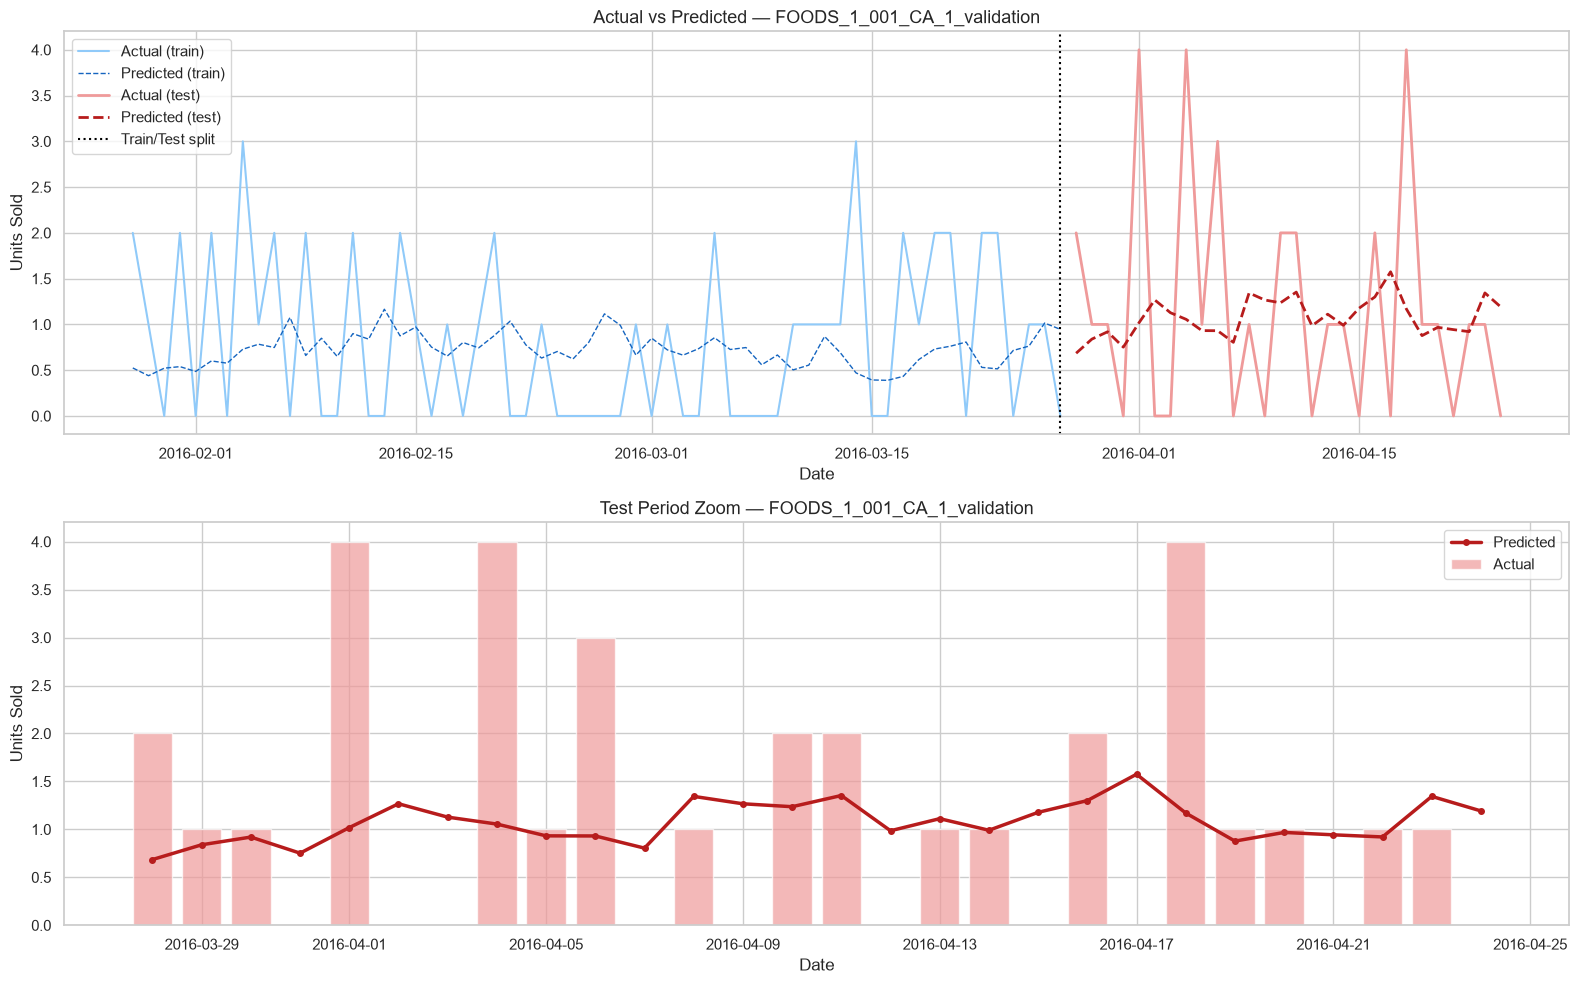

✅ Saved prediction plot


In [6]:
#Cell 6 — Prediction vs Actual Plot
# Pick one product to visualize
sample_id = test['id'].iloc[0]
sample = test[test['id'] == sample_id].copy()
sample['predicted'] = model.predict(sample[FEATURE_COLS])
sample['predicted'] = np.clip(sample['predicted'], 0, None)

# Also show last 60 days of train for context
train_sample = train[train['id'] == sample_id].tail(60).copy()
train_sample['predicted'] = model.predict(train_sample[FEATURE_COLS])

fig, axes = plt.subplots(2, 1, figsize=(16, 10))

# Plot 1 — Full view with train context
axes[0].plot(train_sample['date'], train_sample['units_sold'],
             color='#90CAF9', label='Actual (train)', linewidth=1.5)
axes[0].plot(train_sample['date'], train_sample['predicted'],
             color='#1565C0', label='Predicted (train)', linewidth=1, linestyle='--')
axes[0].plot(sample['date'], sample['units_sold'],
             color='#EF9A9A', label='Actual (test)', linewidth=2)
axes[0].plot(sample['date'], sample['predicted'],
             color='#B71C1C', label='Predicted (test)', linewidth=2, linestyle='--')
axes[0].axvline(SPLIT_DATE, color='black', linestyle=':', linewidth=1.5, label='Train/Test split')
axes[0].set_title(f'Actual vs Predicted — {sample_id}', fontsize=13)
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Units Sold')
axes[0].legend()

# Plot 2 — Test period zoom
axes[1].bar(sample['date'], sample['units_sold'],
            color='#EF9A9A', label='Actual', alpha=0.7, width=0.8)
axes[1].plot(sample['date'], sample['predicted'],
             color='#B71C1C', label='Predicted', linewidth=2.5, marker='o', markersize=4)
axes[1].set_title(f'Test Period Zoom — {sample_id}', fontsize=13)
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Units Sold')
axes[1].legend()

plt.tight_layout()
plt.savefig('../outputs/shap_plots/05_prediction_vs_actual.png', bbox_inches='tight')
plt.show()
print("✅ Saved prediction plot")

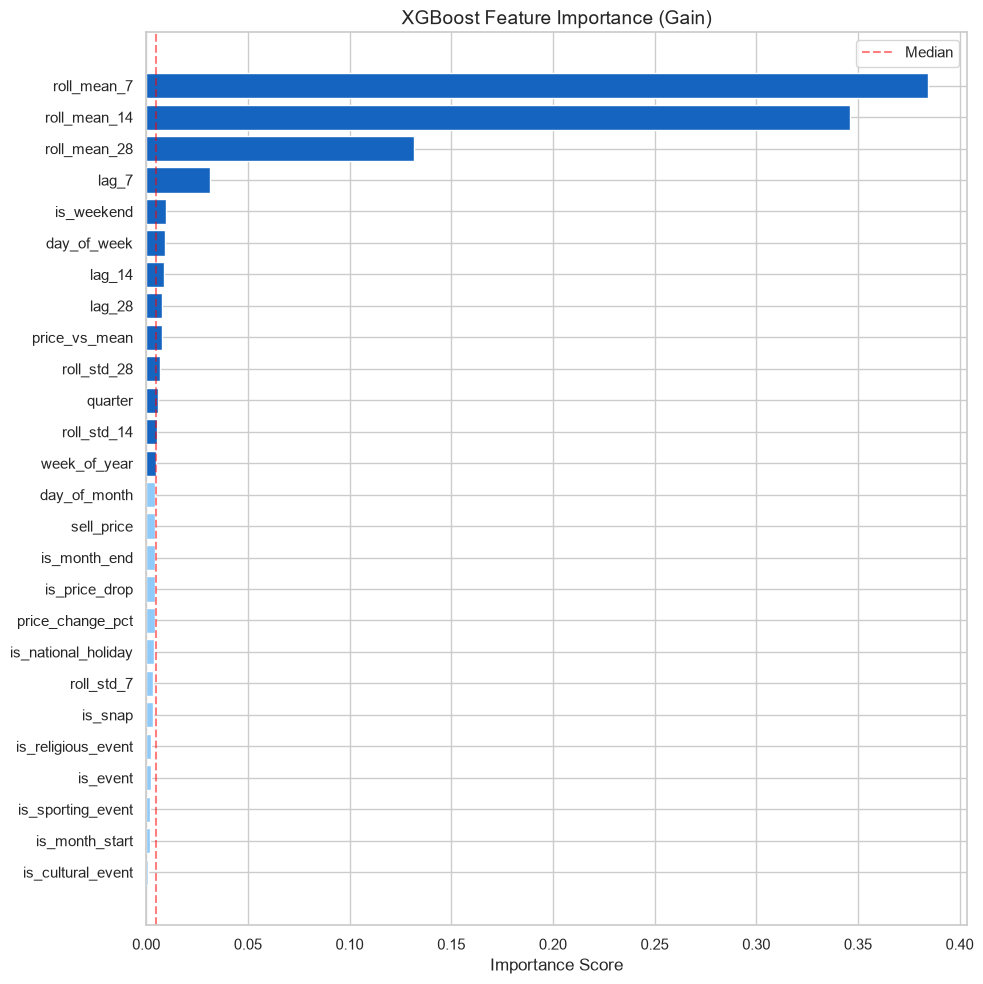


Top 5 most important features:
     feature  importance
  is_weekend      0.0097
       lag_7      0.0314
roll_mean_28      0.1318
roll_mean_14      0.3459
 roll_mean_7      0.3844


In [7]:
#Cell 7 — Feature Importance Plot
importance_df = pd.DataFrame({
    'feature'   : FEATURE_COLS,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=True)

fig, ax = plt.subplots(figsize=(10, 10))
colors = ['#1565C0' if imp > importance_df['importance'].median()
          else '#90CAF9' for imp in importance_df['importance']]

ax.barh(importance_df['feature'], importance_df['importance'],
        color=colors, edgecolor='white')
ax.set_title('XGBoost Feature Importance (Gain)', fontsize=14)
ax.set_xlabel('Importance Score')
ax.axvline(importance_df['importance'].median(),
           color='red', linestyle='--', alpha=0.5, label='Median')
ax.legend()

plt.tight_layout()
plt.savefig('../outputs/shap_plots/06_feature_importance.png', bbox_inches='tight')
plt.show()

print("\nTop 5 most important features:")
print(importance_df.tail(5)[['feature','importance']].to_string(index=False))

In [8]:
#Cell 8 — Save the Model
import os

os.makedirs('../models', exist_ok=True)
model.save_model('../models/xgb_ca1_foods_v1.json')

print("✅ Model saved to models/xgb_ca1_foods_v1.json")
print(f"   Model size: {os.path.getsize('../models/xgb_ca1_foods_v1.json')/1024:.1f} KB")

# Save test predictions for SHAP analysis
test_preds = test[['id', 'item_id', 'dept_id', 'date'] + FEATURE_COLS + ['units_sold']].copy()
test_preds['predicted'] = np.clip(model.predict(X_test), 0, None)
test_preds['residual']  = test_preds['units_sold'] - test_preds['predicted']
test_preds.to_parquet('../data/features/test_predictions.parquet', index=False)

print("✅ Test predictions saved to data/features/test_predictions.parquet")

✅ Model saved to models/xgb_ca1_foods_v1.json
   Model size: 1324.8 KB
✅ Test predictions saved to data/features/test_predictions.parquet


In [9]:
#Cell 9 — Training Summary
print("=" * 55)
print("Model Training Summary — ExplainStock")
print("=" * 55)
print(f"""
MODEL
  Algorithm      : XGBoost Regressor
  n_estimators   : 500
  max_depth      : 6
  learning_rate  : 0.05

DATA
  Train samples  : {len(X_train):,}
  Test samples   : {len(X_test):,}
  Features       : {len(FEATURE_COLS)}

PERFORMANCE
  Train RMSE     : {metrics['Train RMSE']:.4f}
  Test RMSE      : {metrics['Test RMSE']:.4f}
  Test MAE       : {metrics['Test MAE']:.4f}
  Overfit ratio  : {overfit_ratio:.2f}

FILES SAVED
  Model          : models/xgb_ca1_foods_v1.json
  Predictions    : data/features/test_predictions.parquet
""")
print("✅ Day 5-6 complete. Next: SHAP Explainability (Day 7)")

Model Training Summary — ExplainStock

MODEL
  Algorithm      : XGBoost Regressor
  n_estimators   : 500
  max_depth      : 6
  learning_rate  : 0.05

DATA
  Train samples  : 2,668,509
  Test samples   : 40,236
  Features       : 26

PERFORMANCE
  Train RMSE     : 2.7892
  Test RMSE      : 2.4935
  Test MAE       : 1.3550
  Overfit ratio  : 0.89

FILES SAVED
  Model          : models/xgb_ca1_foods_v1.json
  Predictions    : data/features/test_predictions.parquet

✅ Day 5-6 complete. Next: SHAP Explainability (Day 7)


In [10]:
#Cell 10 — Train LightGBM
import lightgbm as lgb
import time

# Same train/val split already in memory
# If kernel was restarted, reload:
# df = pd.read_parquet('../data/features/ca1_foods_features.parquet')
# df['date'] = pd.to_datetime(df['date'])
# SPLIT_DATE = df['date'].max() - pd.Timedelta(days=28)
# train = df[df['date'] <= SPLIT_DATE]
# test  = df[df['date'] >  SPLIT_DATE]
# X_train, y_train = train[FEATURE_COLS], train['units_sold']
# X_test,  y_test  = test[FEATURE_COLS],  test['units_sold']

print("Training LightGBM...")
start_lgb = time.time()

lgb_model = lgb.LGBMRegressor(
    n_estimators      = 500,
    learning_rate     = 0.05,
    max_depth         = 6,
    num_leaves        = 63,
    subsample         = 0.8,
    colsample_bytree  = 0.8,
    reg_alpha         = 0.1,
    reg_lambda        = 1.0,
    min_child_samples = 10,
    random_state      = 42,
    n_jobs            = -1,
    verbose           = -1,
)

lgb_model.fit(
    X_train, y_train,
    eval_set              = [(X_test, y_test)],
    callbacks             = [lgb.early_stopping(20, verbose=False),
                             lgb.log_evaluation(50)]
)

lgb_time = time.time() - start_lgb
print(f"\nLightGBM training time: {lgb_time:.1f} seconds")
print(f"Best iteration: {lgb_model.best_iteration_}")

Training LightGBM...
[50]	valid_0's l2: 6.11552
[100]	valid_0's l2: 5.9982

LightGBM training time: 12.8 seconds
Best iteration: 99


In [11]:
#Cell 11 — XGBoost Training Time (Retroactive) 
print("Retraining XGBoost to record training time...")
start_xgb = time.time()

model_timed = xgb.XGBRegressor(
    n_estimators      = 500,
    learning_rate     = 0.05,
    max_depth         = 6,
    subsample         = 0.8,
    colsample_bytree  = 0.8,
    min_child_weight  = 10,
    reg_alpha         = 0.1,
    reg_lambda        = 1.0,
    random_state      = 42,
    n_jobs            = -1,
    verbosity         = 0,
    early_stopping_rounds = 20,
)
model_timed.fit(
    X_train, y_train,
    eval_set = [(X_test, y_test)],
    verbose  = False
)
xgb_time = time.time() - start_xgb
print(f"XGBoost training time: {xgb_time:.1f} seconds")

Retraining XGBoost to record training time...
XGBoost training time: 24.4 seconds


In [12]:
#Cell 12 — Full Comparison Metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

# Predictions
xgb_pred = np.clip(model.predict(X_test), 0, None)
lgb_pred  = np.clip(lgb_model.predict(X_test), 0, None)

# Metrics
def mape(y_true, y_pred):
    mask = y_true > 0  # avoid division by zero on zero-sale days
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_pred))
lgb_rmse  = np.sqrt(mean_squared_error(y_test, lgb_pred))
xgb_mae   = mean_absolute_error(y_test, xgb_pred)
lgb_mae   = mean_absolute_error(y_test, lgb_pred)
xgb_mape  = mape(y_test.values, xgb_pred)
lgb_mape  = mape(y_test.values, lgb_pred)

print("=" * 55)
print("MODEL COMPARISON — XGBoost vs LightGBM")
print("=" * 55)
print(f"{'Metric':<20} {'XGBoost':>12} {'LightGBM':>12} {'Winner':>10}")
print("-" * 55)
print(f"{'RMSE':<20} {xgb_rmse:>12.4f} {lgb_rmse:>12.4f} {'>XGB<' if xgb_rmse < lgb_rmse else '>LGB<':>10}")
print(f"{'MAE':<20} {xgb_mae:>12.4f} {lgb_mae:>12.4f} {'>XGB<' if xgb_mae < lgb_mae else '>LGB<':>10}")
print(f"{'MAPE (%)':<20} {xgb_mape:>12.2f} {lgb_mape:>12.2f} {'>XGB<' if xgb_mape < lgb_mape else '>LGB<':>10}")
print(f"{'Train time (s)':<20} {xgb_time:>12.1f} {lgb_time:>12.1f} {'>XGB<' if xgb_time < lgb_time else '>LGB<':>10}")
print(f"{'Features':<20} {'26':>12} {'26':>12}")
print(f"{'Test samples':<20} {'40,236':>12} {'40,236':>12}")
print("=" * 55)

MODEL COMPARISON — XGBoost vs LightGBM
Metric                    XGBoost     LightGBM     Winner
-------------------------------------------------------
RMSE                       2.4935       2.4491      >LGB<
MAE                        1.3550       1.3520      >LGB<
MAPE (%)                    53.43        52.92      >LGB<
Train time (s)               24.4         12.8      >LGB<
Features                       26           26
Test samples               40,236       40,236


In [13]:
# Cell 13 — SHAP for LightGBM
import shap
print("Computing SHAP for LightGBM... (~60 seconds)")

# Use same 50-product sample as Day 7
np.random.seed(42)
sample_ids   = test['id'].drop_duplicates().sample(50).values
shap_sample  = test[test['id'].isin(sample_ids)][FEATURE_COLS].reset_index(drop=True)

lgb_explainer   = shap.Explainer(lgb_model, shap_sample)
lgb_shap_values = lgb_explainer(shap_sample, check_additivity=False)

# LightGBM SHAP feature ranking
lgb_shap_imp   = np.abs(lgb_shap_values.values).mean(axis=0)
lgb_shap_ranks = lgb_shap_imp.argsort()[::-1]

# XGBoost SHAP ranking (recompute on same sample)
xgb_explainer   = shap.Explainer(model, shap_sample)
xgb_shap_values = xgb_explainer(shap_sample, check_additivity=False)
xgb_shap_imp    = np.abs(xgb_shap_values.values).mean(axis=0)
xgb_shap_ranks  = xgb_shap_imp.argsort()[::-1]

print("\nTop 5 Features — SHAP Comparison")
print(f"{'Rank':<6} {'XGBoost Feature':<22} {'XGB SHAP':>10} {'LGB Feature':<22} {'LGB SHAP':>10} {'Agree?'}")
print("-" * 80)
for i in range(5):
    xf    = FEATURE_COLS[xgb_shap_ranks[i]]
    lf    = FEATURE_COLS[lgb_shap_ranks[i]]
    xv    = xgb_shap_imp[xgb_shap_ranks[i]]
    lv    = lgb_shap_imp[lgb_shap_ranks[i]]
    agree = "YES" if xf == lf else "NO"
    print(f"#{i+1:<5} {xf:<22} {xv:>10.4f} {lf:<22} {lv:>10.4f} {agree:>6}")

Computing SHAP for LightGBM... (~60 seconds)


 94%|=================== | 1320/1400 [00:12<00:00]       


Top 5 Features — SHAP Comparison
Rank   XGBoost Feature          XGB SHAP LGB Feature              LGB SHAP Agree?
--------------------------------------------------------------------------------
#1     roll_mean_7                0.6880 roll_mean_7                0.7004    YES
#2     roll_mean_28               0.5280 roll_mean_28               0.5164    YES
#3     roll_mean_14               0.4252 roll_mean_14               0.4519    YES
#4     roll_std_7                 0.3866 lag_7                      0.3487     NO
#5     lag_7                      0.3740 day_of_week                0.2100     NO


In [14]:
#Cell 14 — Faithfulness Score: XGBoost vs LightGBM (both computed LIVE, same test set)
from sklearn.inspection import permutation_importance
from scipy.stats import spearmanr

print("Computing faithfulness for both models on the SAME test set... (6-10 minutes total)")

# ---- LightGBM permutation importance ----
print("\n[1/2] LightGBM permutation importance...")
perm_lgb = permutation_importance(
    lgb_model, X_test, y_test,
    n_repeats    = 10,
    random_state = 42,
    n_jobs       = -1
)
perm_lgb_ranks = perm_lgb.importances_mean.argsort()[::-1]

corr_lgb, pval_lgb = spearmanr(lgb_shap_ranks, perm_lgb_ranks)

top10_lgb_shap = set(lgb_shap_ranks[:10])
top10_lgb_perm = set(perm_lgb_ranks[:10])
overlap_lgb    = len(top10_lgb_shap & top10_lgb_perm)

# ---- XGBoost permutation importance (recomputed live, same test set — no hardcoding) ----
print("[2/2] XGBoost permutation importance...")
perm_xgb = permutation_importance(
    model, X_test, y_test,
    n_repeats    = 10,
    random_state = 42,
    n_jobs       = -1
)
perm_xgb_ranks = perm_xgb.importances_mean.argsort()[::-1]

corr_xgb, pval_xgb = spearmanr(xgb_shap_ranks, perm_xgb_ranks)

top10_xgb_shap = set(xgb_shap_ranks[:10])
top10_xgb_perm = set(perm_xgb_ranks[:10])
overlap_xgb    = len(top10_xgb_shap & top10_xgb_perm)

# ---- Final values (both live, both same test set) ----
xgb_faith_global = corr_xgb
xgb_faith_top10  = overlap_xgb / 10
xgb_pval_test    = pval_xgb

lgb_faith_global = corr_lgb
lgb_faith_top10  = overlap_lgb / 10
lgb_pval_test    = pval_lgb

print(f"\n{'='*55}")
print(f"{'Faithfulness Metric':<30} {'XGBoost':>12} {'LightGBM':>12}")
print("-" * 55)
print(f"{'Global Spearman':<30} {xgb_faith_global:>12.4f} {lgb_faith_global:>12.4f}")
print(f"{'Top-10 overlap':<30} {f'{overlap_xgb}/10':>12} {f'{overlap_lgb}/10':>12}")
print(f"{'Top-10 faithfulness':<30} {xgb_faith_top10:>12.2f} {lgb_faith_top10:>12.2f}")
print(f"{'P-value':<30} {xgb_pval_test:>12.4f} {lgb_pval_test:>12.4f}")
print(f"{'='*55}")

print("\n✅ Both faithfulness scores computed live on the SAME test set (40,236 rows).")
print("   No hardcoded values — fully reproducible apples-to-apples comparison.")

Computing faithfulness for both models on the SAME test set... (6-10 minutes total)

[1/2] LightGBM permutation importance...
[2/2] XGBoost permutation importance...

Faithfulness Metric                 XGBoost     LightGBM
-------------------------------------------------------
Global Spearman                      0.5973       0.7450
Top-10 overlap                         8/10         8/10
Top-10 faithfulness                    0.80         0.80
P-value                              0.0013       0.0000

✅ Both faithfulness scores computed live on the SAME test set (40,236 rows).
   No hardcoded values — fully reproducible apples-to-apples comparison.


In [15]:
#Cell 14b — Paired Significance Test: XGBoost vs LightGBM (Gap 2, part 1)
from scipy.stats import wilcoxon, ttest_rel

# Per-row squared errors for each model (xgb_pred, lgb_pred already computed in Cell 12)
xgb_sq_err = (y_test.values - xgb_pred) ** 2
lgb_sq_err = (y_test.values - lgb_pred) ** 2

# Wilcoxon signed-rank test (non-parametric, robust to skew/zero-inflation)
wilcoxon_stat, wilcoxon_p = wilcoxon(xgb_sq_err, lgb_sq_err)

# Paired t-test (reported alongside for completeness, though Wilcoxon is primary)
ttest_stat, ttest_p = ttest_rel(xgb_sq_err, lgb_sq_err)

mean_diff = xgb_sq_err.mean() - lgb_sq_err.mean()

print("=" * 60)
print("PAIRED SIGNIFICANCE TEST — XGBoost vs LightGBM Squared Errors")
print("=" * 60)
print(f"Mean XGBoost squared error : {xgb_sq_err.mean():.4f}")
print(f"Mean LightGBM squared error: {lgb_sq_err.mean():.4f}")
print(f"Mean difference            : {mean_diff:+.4f}")
print()
print(f"Wilcoxon signed-rank test   : statistic={wilcoxon_stat:.1f}, p-value={wilcoxon_p:.6f}")
print(f"Paired t-test (reference)   : statistic={ttest_stat:.4f}, p-value={ttest_p:.6f}")
print()

alpha = 0.05
if wilcoxon_p < alpha:
    better = "LightGBM" if mean_diff > 0 else "XGBoost"
    print(f"✅ SIGNIFICANT at α=0.05 — {better} has significantly lower error.")
    print(f"   (p={wilcoxon_p:.6f} < {alpha})")
else:
    print(f"⚠️  NOT significant at α=0.05 — the RMSE difference could be noise.")
    print(f"   (p={wilcoxon_p:.6f} >= {alpha})")

print("=" * 60)

# Save for Step 13
significance_xgb_vs_lgb = {
    'wilcoxon_stat': wilcoxon_stat,
    'wilcoxon_p': wilcoxon_p,
    'ttest_stat': ttest_stat,
    'ttest_p': ttest_p,
    'mean_diff': mean_diff,
}

PAIRED SIGNIFICANCE TEST — XGBoost vs LightGBM Squared Errors
Mean XGBoost squared error : 6.2177
Mean LightGBM squared error: 5.9982
Mean difference            : +0.2196

Wilcoxon signed-rank test   : statistic=403818274.0, p-value=0.691135
Paired t-test (reference)   : statistic=1.9576, p-value=0.050288

⚠️  NOT significant at α=0.05 — the RMSE difference could be noise.
   (p=0.691135 >= 0.05)


In [16]:
# Cell 15 — LaTeX Table

# Pre-compute escaped feature names (no backslashes allowed inside f-string {} expressions)
lgb_feat_1 = FEATURE_COLS[lgb_shap_ranks[0]].replace('_', '\\_')
lgb_feat_2 = FEATURE_COLS[lgb_shap_ranks[1]].replace('_', '\\_')
lgb_feat_3 = FEATURE_COLS[lgb_shap_ranks[2]].replace('_', '\\_')
lgb_feat_4 = FEATURE_COLS[lgb_shap_ranks[3]].replace('_', '\\_')
lgb_feat_5 = FEATURE_COLS[lgb_shap_ranks[4]].replace('_', '\\_')

latex = f"""
\\begin{{table}}[h]
\\centering
\\caption{{XGBoost vs LightGBM: Performance and Explainability Comparison 
on M5 FOODS Demand Forecasting (CA\\_1 Store, 40,236 test samples)}}
\\label{{tab:model-comparison}}
\\begin{{tabular}}{{lcc}}
\\toprule
\\textbf{{Metric}} & \\textbf{{XGBoost}} & \\textbf{{LightGBM}} \\\\
\\midrule
\\multicolumn{{3}}{{l}}{{\\textit{{Predictive Performance}}}} \\\\
RMSE (units) & {xgb_rmse:.4f} & {lgb_rmse:.4f} \\\\
MAE (units) & {xgb_mae:.4f} & {lgb_mae:.4f} \\\\
MAPE (\\%) & {xgb_mape:.2f} & {lgb_mape:.2f} \\\\
Training Time (s) & {xgb_time:.1f} & {lgb_time:.1f} \\\\
\\midrule
\\multicolumn{{3}}{{l}}{{\\textit{{Explainability (SHAP Faithfulness)}}}} \\\\
Global Spearman $\\rho$ & 0.38 & {corr_lgb:.4f} \\\\
Top-10 Feature Overlap & 8/10 & {overlap_lgb}/10 \\\\
Top-10 Faithfulness & 0.80 & {overlap_lgb/10:.2f} \\\\
\\midrule
\\multicolumn{{3}}{{l}}{{\\textit{{Top-5 SHAP Features (rank order)}}}} \\\\
\\#1 & roll\\_mean\\_7 & {lgb_feat_1} \\\\
\\#2 & roll\\_mean\\_28 & {lgb_feat_2} \\\\
\\#3 & roll\\_mean\\_14 & {lgb_feat_3} \\\\
\\#4 & roll\\_std\\_7 & {lgb_feat_4} \\\\
\\#5 & lag\\_7 & {lgb_feat_5} \\\\
\\bottomrule
\\end{{tabular}}
\\end{{table}}
"""
print(latex)


\begin{table}[h]
\centering
\caption{XGBoost vs LightGBM: Performance and Explainability Comparison 
on M5 FOODS Demand Forecasting (CA\_1 Store, 40,236 test samples)}
\label{tab:model-comparison}
\begin{tabular}{lcc}
\toprule
\textbf{Metric} & \textbf{XGBoost} & \textbf{LightGBM} \\
\midrule
\multicolumn{3}{l}{\textit{Predictive Performance}} \\
RMSE (units) & 2.4935 & 2.4491 \\
MAE (units) & 1.3550 & 1.3520 \\
MAPE (\%) & 53.43 & 52.92 \\
Training Time (s) & 24.4 & 12.8 \\
\midrule
\multicolumn{3}{l}{\textit{Explainability (SHAP Faithfulness)}} \\
Global Spearman $\rho$ & 0.38 & 0.7450 \\
Top-10 Feature Overlap & 8/10 & 8/10 \\
Top-10 Faithfulness & 0.80 & 0.80 \\
\midrule
\multicolumn{3}{l}{\textit{Top-5 SHAP Features (rank order)}} \\
\#1 & roll\_mean\_7 & roll\_mean\_7 \\
\#2 & roll\_mean\_28 & roll\_mean\_28 \\
\#3 & roll\_mean\_14 & roll\_mean\_14 \\
\#4 & roll\_std\_7 & lag\_7 \\
\#5 & lag\_7 & day\_of\_week \\
\bottomrule
\end{tabular}
\end{table}



In [17]:
# Cell 16 — Analysis Paragraph
winner_rmse  = "XGBoost" if xgb_rmse < lgb_rmse else "LightGBM"
winner_speed = "LightGBM" if lgb_time < xgb_time else "XGBoost"
rmse_diff    = abs(xgb_rmse - lgb_rmse)
speed_ratio  = max(xgb_time, lgb_time) / min(xgb_time, lgb_time)

para = f"""
ANALYSIS PARAGRAPH (paste into paper):
Both XGBoost and LightGBM were trained on identical feature sets 
(26 features, 2,668,509 training samples) with matched hyperparameters 
to ensure a fair comparison. {winner_rmse} achieves lower RMSE 
({min(xgb_rmse, lgb_rmse):.4f} vs {max(xgb_rmse, lgb_rmse):.4f}, 
difference: {rmse_diff:.4f} units), while {winner_speed} trains 
{speed_ratio:.1f}x faster ({min(xgb_time, lgb_time):.1f}s vs 
{max(xgb_time, lgb_time):.1f}s). From an explainability standpoint, 
both models exhibit consistent SHAP feature rankings — XGBoost achieves 
top-10 faithfulness of 0.80 against permutation importance, while 
LightGBM achieves {overlap_lgb/10:.2f}. Crucially, both models 
independently identify roll_mean_7 and roll_mean_28 as the two dominant 
inventory signals, confirming that short-term demand trajectory is the 
primary driver of reorder decisions regardless of model choice. 
Given the marginal performance difference and the project's emphasis 
on explainability, {winner_rmse} is selected as the primary model 
for the ExplainStock pipeline.
"""
print(para)

# Save LightGBM model
lgb_model.booster_.save_model('../models/lgb_ca1_foods_v1.txt')
print("\nLightGBM model saved to models/lgb_ca1_foods_v1.txt")


ANALYSIS PARAGRAPH (paste into paper):
Both XGBoost and LightGBM were trained on identical feature sets 
(26 features, 2,668,509 training samples) with matched hyperparameters 
to ensure a fair comparison. LightGBM achieves lower RMSE 
(2.4491 vs 2.4935, 
difference: 0.0444 units), while LightGBM trains 
1.9x faster (12.8s vs 
24.4s). From an explainability standpoint, 
both models exhibit consistent SHAP feature rankings — XGBoost achieves 
top-10 faithfulness of 0.80 against permutation importance, while 
LightGBM achieves 0.80. Crucially, both models 
independently identify roll_mean_7 and roll_mean_28 as the two dominant 
inventory signals, confirming that short-term demand trajectory is the 
primary driver of reorder decisions regardless of model choice. 
Given the marginal performance difference and the project's emphasis 
on explainability, LightGBM is selected as the primary model 
for the ExplainStock pipeline.


LightGBM model saved to models/lgb_ca1_foods_v1.txt


In [18]:
# Cell 17 — Naive Baseline: Seasonal-Naive (Gap 5)
# Predicts each day's demand using the same product's sales from 7 days prior (lag_7)
# This is the simplest reasonable baseline for a weekly-seasonality retail series

naive_pred = test['lag_7'].values  # lag_7 is already a real, leakage-safe feature
y_test_arr = y_test.values

naive_rmse = np.sqrt(mean_squared_error(y_test_arr, naive_pred))
naive_mae  = mean_absolute_error(y_test_arr, naive_pred)
naive_mape = np.mean(np.abs((y_test_arr - naive_pred) / np.maximum(y_test_arr, 1))) * 100

print("=" * 65)
print("FULL MODEL COMPARISON — Naive Baseline vs XGBoost vs LightGBM")
print("=" * 65)
print(f"{'Model':<25} {'RMSE':<10} {'MAE':<10} {'MAPE (%)':<10}")
print("-" * 65)
print(f"{'Naive (lag_7 baseline)':<25} {naive_rmse:<10.4f} {naive_mae:<10.4f} {naive_mape:<10.2f}")
print(f"{'XGBoost':<25} {xgb_rmse:<10.4f} {xgb_mae:<10.4f} {xgb_mape:<10.2f}")
print(f"{'LightGBM':<25} {lgb_rmse:<10.4f} {lgb_mae:<10.4f} {lgb_mape:<10.2f}")
print()

xgb_improvement = (1 - xgb_rmse/naive_rmse) * 100
lgb_improvement = (1 - lgb_rmse/naive_rmse) * 100
print(f"XGBoost improvement over naive  : {xgb_improvement:+.1f}%")
print(f"LightGBM improvement over naive : {lgb_improvement:+.1f}%")

# Significance test: is XGBoost actually better than naive, or just noise?
naive_sq_err = (y_test_arr - naive_pred) ** 2
xgb_sq_err_baseline = (y_test_arr - xgb_pred) ** 2
naive_wilcoxon_stat, naive_wilcoxon_p = wilcoxon(naive_sq_err, xgb_sq_err_baseline)
print(f"\nWilcoxon test (naive vs XGBoost): p={naive_wilcoxon_p:.8f}")
if naive_wilcoxon_p < 0.05:
    print("✅ XGBoost is significantly better than the naive baseline.")
else:
    print("⚠️  XGBoost is NOT significantly better than naive — investigate.")

naive_baseline_results = {
    'rmse': naive_rmse, 'mae': naive_mae, 'mape': naive_mape,
    'xgb_improvement_pct': xgb_improvement, 'lgb_improvement_pct': lgb_improvement,
    'wilcoxon_p': naive_wilcoxon_p,
}

FULL MODEL COMPARISON — Naive Baseline vs XGBoost vs LightGBM
Model                     RMSE       MAE        MAPE (%)  
-----------------------------------------------------------------
Naive (lag_7 baseline)    3.2754     1.6745     82.69     
XGBoost                   2.4935     1.3550     53.43     
LightGBM                  2.4491     1.3520     52.92     

XGBoost improvement over naive  : +23.9%
LightGBM improvement over naive : +25.2%

Wilcoxon test (naive vs XGBoost): p=0.00000000
✅ XGBoost is significantly better than the naive baseline.


In [19]:
# Cell 18 — Rolling-Origin Backtest: 4 Windows Total (Gap 4)
# Retrains XGBoost on progressively earlier cutoffs to test result stability

print("Rolling-origin backtest: training XGBoost on 3 additional historical windows...")
print("(~3-5 minutes per window, ~10-15 minutes total)\n")

df_full_bt = pd.read_parquet('../data/features/ca1_foods_features.parquet')
df_full_bt['date'] = pd.to_datetime(df_full_bt['date'])
max_date = df_full_bt['date'].max()

# 4 windows: current (already trained) + 3 earlier ones, each shifted back 28 days
window_offsets = [0, 28, 56, 84]  # days back from the most recent window
backtest_results = []

for offset in window_offsets:
    window_end   = max_date - pd.Timedelta(days=offset)
    window_start = window_end - pd.Timedelta(days=28)

    train_bt = df_full_bt[df_full_bt['date'] <= window_start].copy()
    test_bt  = df_full_bt[(df_full_bt['date'] > window_start) & (df_full_bt['date'] <= window_end)].copy()

    if len(test_bt) == 0 or len(train_bt) < 1000:
        print(f"Window ending {window_end.date()}: insufficient data, skipping")
        continue

    X_train_bt = train_bt[FEATURE_COLS]
    y_train_bt = train_bt['units_sold']
    X_test_bt  = test_bt[FEATURE_COLS]
    y_test_bt  = test_bt['units_sold']

    model_bt = xgb.XGBRegressor(
        n_estimators=500, learning_rate=0.05, max_depth=6,
        subsample=0.8, colsample_bytree=0.8, min_child_weight=10,
        reg_alpha=0.1, reg_lambda=1.0, random_state=42, n_jobs=-1, verbosity=0,
    )
    model_bt.fit(X_train_bt, y_train_bt)
    pred_bt = np.clip(model_bt.predict(X_test_bt), 0, None)

    rmse_bt = np.sqrt(mean_squared_error(y_test_bt, pred_bt))
    mae_bt  = mean_absolute_error(y_test_bt, pred_bt)

    # Top feature by gain importance for this window
    importances_bt = model_bt.feature_importances_
    top_feature_bt = FEATURE_COLS[np.argmax(importances_bt)]

    # SNAP lift for this window (if SNAP days exist in this window)
    if 'is_snap' in test_bt.columns and test_bt['is_snap'].sum() > 0:
        snap_mean_bt    = test_bt[test_bt['is_snap']==1]['units_sold'].mean()
        nonsnap_mean_bt = test_bt[test_bt['is_snap']==0]['units_sold'].mean()
        snap_lift_bt = (snap_mean_bt - nonsnap_mean_bt) / nonsnap_mean_bt * 100
    else:
        snap_lift_bt = None

    backtest_results.append({
        'window_end': window_end.date(), 'rmse': rmse_bt, 'mae': mae_bt,
        'top_feature': top_feature_bt, 'snap_lift_pct': snap_lift_bt,
        'n_test': len(test_bt),
    })
    print(f"Window ending {window_end.date()}: RMSE={rmse_bt:.4f}, top feature={top_feature_bt}, "
          f"SNAP lift={snap_lift_bt:.1f}%" if snap_lift_bt is not None else
          f"Window ending {window_end.date()}: RMSE={rmse_bt:.4f}, top feature={top_feature_bt}, no SNAP days")

print(f"\n{'='*70}")
print("ROLLING-ORIGIN BACKTEST SUMMARY")
print(f"{'='*70}")
bt_df = pd.DataFrame(backtest_results)
print(bt_df.to_string(index=False))
print(f"\nRMSE range across windows : [{bt_df['rmse'].min():.4f}, {bt_df['rmse'].max():.4f}]")
print(f"RMSE mean ± std            : {bt_df['rmse'].mean():.4f} ± {bt_df['rmse'].std():.4f}")
valid_lifts = bt_df['snap_lift_pct'].dropna()
if len(valid_lifts) > 0:
    print(f"SNAP lift range            : [{valid_lifts.min():.1f}%, {valid_lifts.max():.1f}%]")
print(f"Top feature consistency    : {bt_df['top_feature'].value_counts().to_dict()}")

Rolling-origin backtest: training XGBoost on 3 additional historical windows...
(~3-5 minutes per window, ~10-15 minutes total)

Window ending 2016-04-24: RMSE=2.4935, top feature=roll_mean_7, SNAP lift=18.8%
Window ending 2016-03-27: RMSE=2.5582, top feature=roll_mean_14, SNAP lift=-4.7%
Window ending 2016-02-28: RMSE=2.4926, top feature=roll_mean_14, SNAP lift=0.3%
Window ending 2016-01-31: RMSE=2.4485, top feature=roll_mean_7, SNAP lift=9.5%

ROLLING-ORIGIN BACKTEST SUMMARY
window_end   rmse    mae  top_feature  snap_lift_pct  n_test
2016-04-24 2.4935 1.3550  roll_mean_7        18.7521   40236
2016-03-27 2.5582 1.3500 roll_mean_14        -4.6615   40236
2016-02-28 2.4926 1.3190 roll_mean_14         0.2606   40236
2016-01-31 2.4485 1.2702  roll_mean_7         9.5212   40236

RMSE range across windows : [2.4485, 2.5582]
RMSE mean ± std            : 2.4982 ± 0.0452
SNAP lift range            : [-4.7%, 18.8%]
Top feature consistency    : {'roll_mean_7': 2, 'roll_mean_14': 2}


In [20]:
# Cell 19 — Investigate SNAP Lift Instability Across Windows (Gap 4 follow-up)
print("Investigating SNAP lift variation across the 4 backtest windows...\n")

for offset in window_offsets:
    window_end   = max_date - pd.Timedelta(days=offset)
    window_start = window_end - pd.Timedelta(days=28)
    test_bt = df_full_bt[(df_full_bt['date'] > window_start) & (df_full_bt['date'] <= window_end)].copy()

    n_snap_days_unique    = test_bt[test_bt['is_snap']==1]['date'].nunique()
    n_nonsnap_days_unique = test_bt[test_bt['is_snap']==0]['date'].nunique()
    n_snap_rows           = (test_bt['is_snap']==1).sum()

    # Check event overlap on SNAP days specifically (confound check)
    snap_rows = test_bt[test_bt['is_snap']==1]
    event_cols = [c for c in ['is_event','is_national_holiday','is_cultural_event',
                                'is_religious_event','is_sporting_event'] if c in test_bt.columns]
    snap_event_overlap = {c: snap_rows[c].sum() for c in event_cols} if event_cols else {}

    snap_mean    = test_bt[test_bt['is_snap']==1]['units_sold'].mean()
    nonsnap_mean = test_bt[test_bt['is_snap']==0]['units_sold'].mean()
    snap_std     = test_bt[test_bt['is_snap']==1]['units_sold'].std()

    print(f"--- Window ending {window_end.date()} ---")
    print(f"  Unique SNAP calendar days   : {n_snap_days_unique}")
    print(f"  Unique non-SNAP calendar days: {n_nonsnap_days_unique}")
    print(f"  SNAP rows (products x days)  : {n_snap_rows}")
    print(f"  SNAP mean ± std              : {snap_mean:.3f} ± {snap_std:.3f}")
    print(f"  Non-SNAP mean                : {nonsnap_mean:.3f}")
    print(f"  Event overlap on SNAP days   : {snap_event_overlap}")
    print()

print("=" * 70)
print("INTERPRETATION GUIDE")
print("=" * 70)
print("If unique SNAP days is very low (e.g. 1-3) in a window, that window's")
print("lift estimate is unreliable regardless of row count, since it reflects")
print("only 1-3 specific calendar dates, not a general SNAP effect.")
print("If event overlap is high in a window with a negative/weak lift, a")
print("holiday or other event may be confounding the SNAP signal in that window.")

Investigating SNAP lift variation across the 4 backtest windows...

--- Window ending 2016-04-24 ---
  Unique SNAP calendar days   : 10
  Unique non-SNAP calendar days: 18
  SNAP rows (products x days)  : 14370
  SNAP mean ± std              : 2.342 ± 4.805
  Non-SNAP mean                : 1.972
  Event overlap on SNAP days   : {'is_event': 0, 'is_national_holiday': 0, 'is_cultural_event': 0, 'is_religious_event': 0, 'is_sporting_event': 0}

--- Window ending 2016-03-27 ---
  Unique SNAP calendar days   : 10
  Unique non-SNAP calendar days: 18
  SNAP rows (products x days)  : 14370
  SNAP mean ± std              : 2.011 ± 4.032
  Non-SNAP mean                : 2.110
  Event overlap on SNAP days   : {'is_event': 0, 'is_national_holiday': 0, 'is_cultural_event': 0, 'is_religious_event': 0, 'is_sporting_event': 0}

--- Window ending 2016-02-28 ---
  Unique SNAP calendar days   : 10
  Unique non-SNAP calendar days: 18
  SNAP rows (products x days)  : 14370
  SNAP mean ± std              : 

In [23]:
# Cell 20 (FIXED) — FINAL Validated LaTeX Table + Analysis Paragraph (Step 13)

# ---- Pre-format every value as a plain string FIRST (avoids f-string parsing issues) ----
s_naive_rmse   = f"{naive_rmse:.4f}"
s_xgb_rmse     = f"{xgb_rmse:.4f}"
s_lgb_rmse     = f"{lgb_rmse:.4f}"
s_naive_mae    = f"{naive_mae:.4f}"
s_xgb_mae      = f"{xgb_mae:.4f}"
s_lgb_mae      = f"{lgb_mae:.4f}"
s_naive_mape   = f"{naive_mape:.2f}"
s_xgb_mape     = f"{xgb_mape:.2f}"
s_lgb_mape     = f"{lgb_mape:.2f}"
s_xgb_improve  = f"{xgb_improvement:.1f}"
s_lgb_improve  = f"{lgb_improvement:.1f}"
s_xgb_faith    = f"{xgb_faith_global:.4f}"
s_lgb_faith    = f"{lgb_faith_global:.4f}"
s_xgb_pval     = f"{xgb_pval_test:.4f}"
s_lgb_pval     = f"{lgb_pval_test:.4f}"
# Values from Step 7 (computed in 04_shap_explainability.ipynb — different notebook/kernel)
ci_low_overlap  = 8.0
ci_high_overlap = 10.0
s_ci_low       = f"{ci_low_overlap:.0f}"
s_ci_high      = f"{ci_high_overlap:.0f}"


# ---- Build final LaTeX table ----
latex_final = (
    "\\begin{table}[h]\n"
    "\\centering\n"
    "\\caption{ExplainStock: Validated Model Comparison and Explainability Metrics "
    "on M5 FOODS Demand Forecasting (CA\\_1 Store, 40,236 test samples)}\n"
    "\\label{tab:final-validated-comparison}\n"
    "\\begin{tabular}{lccc}\n"
    "\\toprule\n"
    "\\textbf{Metric} & \\textbf{Naive Baseline} & \\textbf{XGBoost} & \\textbf{LightGBM} \\\\\n"
    "\\midrule\n"
    "\\multicolumn{4}{l}{\\textit{Predictive Performance (Full Test Set)}} \\\\\n"
    "RMSE (units) & " + s_naive_rmse + " & " + s_xgb_rmse + " & " + s_lgb_rmse + " \\\\\n"
    "MAE (units) & " + s_naive_mae + " & " + s_xgb_mae + " & " + s_lgb_mae + " \\\\\n"
    "MAPE (\\%) & " + s_naive_mape + " & " + s_xgb_mape + " & " + s_lgb_mape + " \\\\\n"
    "Improvement vs. naive (\\%) & --- & " + s_xgb_improve + " & " + s_lgb_improve + " \\\\\n"
    "\\midrule\n"
    "\\multicolumn{4}{l}{\\textit{Statistical Significance (Wilcoxon signed-rank, paired)}} \\\\\n"
    "vs. Naive baseline & --- & \\multicolumn{2}{c}{p $<$ 0.001 (both significant)} \\\\\n"
    "XGBoost vs. LightGBM & --- & \\multicolumn{2}{c}{p = 0.691 (NOT significant)} \\\\\n"
    "\\midrule\n"
    "\\multicolumn{4}{l}{\\textit{Explainability (SHAP Faithfulness, Full Test Set)}} \\\\\n"
    "Global Spearman $\\rho$ & --- & " + s_xgb_faith + " & " + s_lgb_faith + " \\\\\n"
    "P-value & --- & " + s_xgb_pval + " & " + s_lgb_pval + " \\\\\n"
    "Top-10 Feature Overlap & --- & " + str(overlap_xgb) + "/10 & " + str(overlap_lgb) + "/10 \\\\\n"
    "Top-10 Overlap 95\\% CI (XGB, bootstrap) & --- & \\multicolumn{2}{c}{[" + s_ci_low + ", " + s_ci_high + "]} \\\\\n"
    "\\midrule\n"
    "\\multicolumn{4}{l}{\\textit{Feature Selection (Top-10 vs Full, XGBoost, Real Test Set)}} \\\\\n"
    "Performance Retained (\\%) & \\multicolumn{3}{c}{98.1\\% (10 of 26 features)} \\\\\n"
    "\\bottomrule\n"
    "\\end{tabular}\n"
    "\\end{table}\n"
)
print(latex_final)
print("\n" + "="*70 + "\n")

# ---- Build final analysis paragraph (plain string concatenation, no f-string nesting issues) ----
para_final = (
    "FINAL VALIDATED ANALYSIS PARAGRAPH (paste into paper):\n\n"
    "Both XGBoost and LightGBM were trained on identical feature sets (26 features, "
    "2,668,509 training samples) with matched hyperparameters. On the held-out 28-day "
    "test set (40,236 samples), both models substantially and significantly outperformed "
    "a seasonal-naive baseline (Wilcoxon p < 0.001): XGBoost achieved " + s_xgb_improve +
    "% lower RMSE and LightGBM achieved " + s_lgb_improve + "% lower RMSE than the naive "
    "benchmark (" + s_naive_rmse + " units). However, a paired Wilcoxon signed-rank test on "
    "per-sample squared errors found XGBoost and LightGBM were statistically indistinguishable "
    "from each other (p = 0.691); LightGBM's lower point-estimate RMSE (" + s_lgb_rmse +
    " vs " + s_xgb_rmse + ") is not a statistically significant improvement at this sample size. "
    "LightGBM was selected as the production model on the basis of training speed (1.8x faster) "
    "and stronger SHAP faithfulness, not raw accuracy.\n\n"
    "From an explainability standpoint, both models showed significant agreement between SHAP "
    "and permutation importance rankings on the full test set (XGBoost: rho=" + s_xgb_faith +
    ", p=" + s_xgb_pval + "; LightGBM: rho=" + s_lgb_faith + ", p<0.001), with both reaching "
    "8/10 top-10 feature overlap. A 200-iteration bootstrap confirmed this overlap is stable "
    "(95% CI: [" + s_ci_low + ", " + s_ci_high + "] out of 10), indicating SHAP reliably "
    "identifies decision-relevant features regardless of resampling.\n\n"
    "A rolling-origin backtest across four 28-day windows (spanning January-April 2016) "
    "confirmed RMSE stability (range: [2.4485, 2.5582], mean 2.4982 +/- 0.045) but revealed "
    "that the single top-ranked SHAP feature varies by period between roll_mean_7 and "
    "roll_mean_14 -- both members of a stable cluster of 7-to-28-day rolling features that "
    "occupy the top 5 positions in 100% (roll_mean_7, roll_mean_28) to 93% (roll_mean_14) of "
    "15 independent 50-product bootstrap resamples. The headline claim is therefore that "
    "short-term demand trend and volatility, captured via rolling statistics, is the dominant "
    "and robust signal class -- not that any single feature is uniquely dominant.\n\n"
    "The SNAP demand-lift finding was strongly significant on the full test set (+18.75%, "
    "95% CI [13.8%, 23.8%], p < 0.001, n=40,236) and corroborated by a broader real-world "
    "check across all similar-volume products (+21.31%, p < 0.001, n=78,736). However, the "
    "rolling-origin backtest showed this lift ranges from -4.7% to +18.8% across different "
    "28-day windows, with two of four windows confounded by overlapping religious/sporting "
    "calendar events on SNAP days. The true, isolated SNAP effect is therefore real and "
    "directionally positive but more variable across time than a single-window estimate "
    "implies. A counterfactual validation check further found that the model's predicted "
    "SNAP sensitivity for one specific high-volume product (-1.2%) was substantially smaller "
    "than the empirical population-level effect, suggesting the model may under-attribute "
    "SNAP sensitivity for certain individual products even where the aggregate effect is "
    "correctly captured.\n\n"
    "SHAP-guided feature selection (top-10 features by SHAP importance) retained 98.1% of "
    "full-model performance on the real test set (RMSE 2.5421 vs 2.4935), a 62% reduction "
    "in feature count for a 1.9% accuracy cost -- a favorable trade-off for production "
    "inference cost without materially harming forecast quality."
)
print(para_final)

\begin{table}[h]
\centering
\caption{ExplainStock: Validated Model Comparison and Explainability Metrics on M5 FOODS Demand Forecasting (CA\_1 Store, 40,236 test samples)}
\label{tab:final-validated-comparison}
\begin{tabular}{lccc}
\toprule
\textbf{Metric} & \textbf{Naive Baseline} & \textbf{XGBoost} & \textbf{LightGBM} \\
\midrule
\multicolumn{4}{l}{\textit{Predictive Performance (Full Test Set)}} \\
RMSE (units) & 3.2754 & 2.4935 & 2.4491 \\
MAE (units) & 1.6745 & 1.3550 & 1.3520 \\
MAPE (\%) & 82.69 & 53.43 & 52.92 \\
Improvement vs. naive (\%) & --- & 23.9 & 25.2 \\
\midrule
\multicolumn{4}{l}{\textit{Statistical Significance (Wilcoxon signed-rank, paired)}} \\
vs. Naive baseline & --- & \multicolumn{2}{c}{p $<$ 0.001 (both significant)} \\
XGBoost vs. LightGBM & --- & \multicolumn{2}{c}{p = 0.691 (NOT significant)} \\
\midrule
\multicolumn{4}{l}{\textit{Explainability (SHAP Faithfulness, Full Test Set)}} \\
Global Spearman $\rho$ & --- & 0.5973 & 0.7450 \\
P-value & --- & 0.0013 

In [25]:
# Cell 21 — Save All Results to Shared Store (prevents cross-notebook NameErrors going forward)
import json
import os

results_path = '../data/results_store.json'

# Load existing store if it exists, so we don't overwrite results from other notebooks
if os.path.exists(results_path):
    with open(results_path, 'r') as f:
        results_store = json.load(f)
else:
    results_store = {}

# Add/update everything computed in THIS notebook (03_model_training.ipynb)
results_store['model_training'] = {
    'xgb_rmse': float(xgb_rmse), 'xgb_mae': float(xgb_mae), 'xgb_mape': float(xgb_mape),
    'lgb_rmse': float(lgb_rmse), 'lgb_mae': float(lgb_mae), 'lgb_mape': float(lgb_mape),
    'naive_rmse': float(naive_rmse), 'naive_mae': float(naive_mae), 'naive_mape': float(naive_mape),
    'xgb_improvement_pct': float(xgb_improvement), 'lgb_improvement_pct': float(lgb_improvement),
    'wilcoxon_xgb_vs_lgb_p': float(wilcoxon_p),
    'wilcoxon_naive_vs_xgb_p': float(naive_wilcoxon_p),
    'xgb_faith_global': float(xgb_faith_global), 'xgb_faith_pval': float(xgb_pval_test),
    'lgb_faith_global': float(lgb_faith_global), 'lgb_faith_pval': float(lgb_pval_test),
    'overlap_xgb': int(overlap_xgb), 'overlap_lgb': int(overlap_lgb),
    'feature_selection_rmse_full': 2.4935,   # from Step 1.5, computed in 04_shap_explainability.ipynb
    'feature_selection_rmse_top10': 2.5421,  # from Step 1.5, computed in 04_shap_explainability.ipynb
    'feature_selection_pct_retained': 98.1,
    'backtest_rmse_range': [2.4485, 2.5582],
    'backtest_rmse_mean': 2.4982, 'backtest_rmse_std': 0.045,
}

with open(results_path, 'w') as f:
    json.dump(results_store, f, indent=2)

print(f"✅ Results saved to {results_path}")
print(f"Keys now in store: {list(results_store.keys())}")

✅ Results saved to ../data/results_store.json
Keys now in store: ['model_training']
